# 自动化特征工程

在`menu_feature_enginer.ipynb`中，我们手动进行了特征工程。

这个notebook中，我们通过`featuretools`实现自动化这个过程。


关于featuretools说明：

- woodwork 为字段赋予逻辑类型和语义标签：
  - 比如int64这些，可以分为邮政编码、手机号、等等
- featuretools 利用woodwork生成的table再去 自动特征

[featuretools](https://featuretools.alteryx.com/en/stable/)

[woodwork](https://woodwork.alteryx.com/en/stable/) 


文中目前并没有用到woodwork赋值语义，目前都是让他自动推断的。

## 导入

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import featuretools as ft
import warnings
warnings.filterwarnings('ignore')

import woodwork as ww
import gc
gc.enable()

print('ft', ft.__version__)
print('np', np.__version__)
print('pd', pd.__version__)

ft 1.31.0
np 1.26.4
pd 2.3.1


In [2]:
application_train = pd.read_csv('data/application_train.csv')
application_test = pd.read_csv('data/application_test.csv')
bureau = pd.read_csv('data/bureau.csv')
bureau_balance = pd.read_csv('data/bureau_balance.csv')
credit_card_balance = pd.read_csv('data/credit_card_balance.csv')
installments_payments = pd.read_csv('data/installments_payments.csv')
previous_application = pd.read_csv('data/previous_application.csv')
pos_cash_balance = pd.read_csv('data/POS_CASH_balance.csv')


In [3]:
application_train['set'] = 'train'
application_test['set'] = 'test'
application_test['TARGET'] = np.nan
print(application_train.shape, application_test.shape)

(307511, 123) (48744, 123)


In [4]:
app = pd.concat([application_train, application_test], ignore_index=True)

我们让测试集和训练集一起进行特征工程，这也是符合的。

有一些字段不应该参与特征工程，我们保留下来，最后合并

In [32]:
app_target = app[['SK_ID_CURR', 'TARGET']]
app_set = app[['SK_ID_CURR', 'set']]
app_for_es = app.drop(columns=['set', 'TARGET']) 

In [6]:
app_for_es.shape

(356255, 121)

## 创建一个entityset
- entity表示一个表；他必须有主键唯一的列。比如`sk_id_curr`
- entity set 表示一组表及其关系

`add_dataframe` 会将 df转为 woodwork的table

In [7]:
app_for_es['SK_ID_CURR'].unique()

array([100002, 100003, 100004, ..., 456223, 456224, 456250], dtype=int64)

In [8]:
es = ft.EntitySet(id='clients')

# 有主键唯一列
es = es.add_dataframe(dataframe_name="app", dataframe=app_for_es, index="SK_ID_CURR")
es = es.add_dataframe(dataframe_name="bureau", dataframe=bureau, index="SK_ID_BUREAU")
es = es.add_dataframe(dataframe_name="previous", dataframe=previous_application, index="SK_ID_PREV")

# 没有主键唯一的列，需要make_index, 创建一列主键
es = es.add_dataframe(dataframe_name="bureau_balance", dataframe=bureau_balance, make_index = True, index = 'bureaubalance_index')
es = es.add_dataframe(dataframe_name="credit", dataframe=credit_card_balance, make_index=True, index='credit_index')
es = es.add_dataframe(dataframe_name="installments", dataframe=installments_payments, make_index=True, index='installments_index')
es = es.add_dataframe(dataframe_name="cash", dataframe=pos_cash_balance,make_index=True, index="cash_index")

In [9]:
es

Entityset: clients
  DataFrames:
    app [Rows: 356255, Columns: 121]
    bureau [Rows: 1716428, Columns: 17]
    previous [Rows: 1670214, Columns: 37]
    bureau_balance [Rows: 27299925, Columns: 4]
    credit [Rows: 3840312, Columns: 24]
    installments [Rows: 13605401, Columns: 9]
    cash [Rows: 10001358, Columns: 9]
  Relationships:
    No relationships

## 为entityset添加replationship
需要为这几个表建立关系：一对多等， 类似父子

In [10]:
# 父亲dfname, 父亲列名； 字dfname, 子列名
es = es.add_relationship("app", "SK_ID_CURR", "bureau", "SK_ID_CURR")
es = es.add_relationship("bureau", "SK_ID_BUREAU", "bureau_balance", "SK_ID_BUREAU")

es = es.add_relationship("app", "SK_ID_CURR", "previous", "SK_ID_CURR")
es = es.add_relationship("previous", "SK_ID_PREV", "cash", "SK_ID_PREV")
es = es.add_relationship("previous", "SK_ID_PREV", "installments", "SK_ID_PREV")
es = es.add_relationship("previous", "SK_ID_PREV", "credit", "SK_ID_PREV")

In [11]:
es

Entityset: clients
  DataFrames:
    app [Rows: 356255, Columns: 121]
    bureau [Rows: 1716428, Columns: 17]
    previous [Rows: 1670214, Columns: 37]
    bureau_balance [Rows: 27299925, Columns: 4]
    credit [Rows: 3840312, Columns: 24]
    installments [Rows: 13605401, Columns: 9]
    cash [Rows: 10001358, Columns: 9]
  Relationships:
    bureau.SK_ID_CURR -> app.SK_ID_CURR
    bureau_balance.SK_ID_BUREAU -> bureau.SK_ID_BUREAU
    previous.SK_ID_CURR -> app.SK_ID_CURR
    cash.SK_ID_PREV -> previous.SK_ID_PREV
    installments.SK_ID_PREV -> previous.SK_ID_PREV
    credit.SK_ID_PREV -> previous.SK_ID_PREV

我们现在就准备好了entityset


## feature primitive
用于entityset的操作，代表了之前手动特征的操作。分为两类：
- `agg`: 输出一个值
- `transform`：输出向量

In [12]:
# 内置原语
ft.list_primitives().head()

,name,type,description,valid_inputs,return_type
0,max_min_delta,aggregation,Determines the difference between the max and ...,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Semantic Tags = ['numeric'])>
1,max_consecutive_negatives,aggregation,Determines the maximum number of consecutive n...,"<ColumnSchema (Logical Type = Double)>, <Colum...",<ColumnSchema (Logical Type = Integer) (Semant...
2,any,aggregation,Determines if any value is 'True' in a list.,<ColumnSchema (Logical Type = BooleanNullable)...,<ColumnSchema (Logical Type = Boolean)>
3,count_inside_nth_std,aggregation,Determines the count of observations that lie ...,<ColumnSchema (Semantic Tags = ['numeric'])>,<ColumnSchema (Logical Type = Integer) (Semant...
4,trend,aggregation,Calculates the trend of a column over time.,"<ColumnSchema (Semantic Tags = ['numeric'])>, ...",<ColumnSchema (Semantic Tags = ['numeric'])>


## deep feature synthesis
就是在多层表关系中，不断agg。 比如`MAX(previous(MEAN(installments.payment))))` 这对人来说很难理解的很多时候。

这和`menu_feature_enginer.ipynb` 手动对banlance进行多层聚合到app上，是一样的。

我们不应该过度追求多的原语操作， 这回造成维度灾难，

默认的，我们不需要指定分开 categorical和numeric列，ft会自动识别类型，进行聚合，转换

因此，这个过程也不涉及编码的操作。

类别列：`mode` 众数， `num_unique` 一共有多少特征

In [13]:
%%time
default_agg_primitives = ["count", "mean", "max", 'sum', 'std', "mode", "num_unique"]
default_trans_primitives =  ["month", "weekday"]

# 返回特征矩阵； 特征
feature_matrix, features = ft.dfs(
    entityset = es,
    target_dataframe_name = 'app', # 最后要关联到这个表，以这个为主
    agg_primitives= default_agg_primitives,
    trans_primitives=default_trans_primitives,
    max_depth=2,
)

CPU times: total: 28min 23s
Wall time: 29min 6s


这一步是最大的耗时操作，经历了30min

- feature_matrix就是df， 
- features元素是feature对象，记录了生成过程。
  - 通过 `.get_name()`获取特征名字

## 特征选择
featuretools 也提供了一些维度进行特征选择：
- 移除大量空的列：ft.selection.remove_highly_null_features
- 移除只有单一值得特征：ft.selection.remove_single_value_features
- 移除高度相关得特征：ft.selection.remove_highly_correlated_features


In [14]:
from featuretools import selection

In [15]:
feature_matrix, features = selection.remove_highly_null_features(feature_matrix, features)

In [16]:
print(feature_matrix.shape)

(356255, 1216)


In [17]:
feature_matrix, features  = selection.remove_single_value_features(feature_matrix, features)

In [18]:
print(feature_matrix.shape)

(356255, 1169)


In [19]:
%%time
feature_matrix, features = selection.remove_highly_correlated_features(feature_matrix, features)

CPU times: total: 36min 12s
Wall time: 35min 41s


```{warning} 性能警告
计算相关系数矩阵是一个极其**耗时**的操作。

对于相关性分析的进一步认识：

Pearson 相关系数仅在衡量**连续变量**之间的**线性关系**时有意义。对于非线性关系或离散特征，其结果可能产生误导。比如：我们不应该对onehot分类变量进行相关分析，它们之间存在严格的线性关系（例如：$type_a+ type_b = 1$），

In [20]:
print(feature_matrix.shape)

(356255, 589)


In [21]:
feature_matrix.head()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,...,STD(credit.previous.NFLAG_INSURED_ON_APPROVAL),STD(credit.previous.SELLERPLACE_AREA),SUM(credit.previous.AMT_ANNUITY),SUM(credit.previous.AMT_APPLICATION),SUM(credit.previous.AMT_DOWN_PAYMENT),SUM(credit.previous.DAYS_FIRST_DRAWING),SUM(credit.previous.DAYS_LAST_DUE),SUM(credit.previous.DAYS_TERMINATION),SUM(credit.previous.RATE_DOWN_PAYMENT),SUM(credit.previous.SELLERPLACE_AREA)
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100002,Cash loans,M,False,True,0,202500.0,406597.5,24700.5,Unaccompanied,Working,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100003,Cash loans,F,False,False,0,270000.0,1293502.5,35698.5,Family,State servant,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100004,Revolving loans,M,True,True,0,67500.0,135000.0,6750.0,Unaccompanied,Working,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100006,Cash loans,F,False,True,0,135000.0,312682.5,29686.5,Unaccompanied,Working,...,0.0,0.0,81000.0,1620000.0,0.0,2191458.0,2191458.0,2191458.0,0.0,-6.0
100007,Cash loans,M,False,True,0,121500.0,513000.0,21865.5,Unaccompanied,Working,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
feature_matrix.to_parquet("ft_feature_matrix.parquet")
ft.save_features(features, "ft_feature_definitions.json")

上面的计算太不容易了，我们将特征矩阵保存下来

In [26]:
feature_matrix.shape

(356255, 1233)

In [27]:
feature_matrix.head()

,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,...,MODE(credit.previous.PRODUCT_COMBINATION)_POS mobile without interest,MODE(credit.previous.PRODUCT_COMBINATION)_POS other with interest,MODE(credit.previous.PRODUCT_COMBINATION)_POS others without interest,MODE(credit.previous.WEEKDAY_APPR_PROCESS_START)_FRIDAY,MODE(credit.previous.WEEKDAY_APPR_PROCESS_START)_MONDAY,MODE(credit.previous.WEEKDAY_APPR_PROCESS_START)_SATURDAY,MODE(credit.previous.WEEKDAY_APPR_PROCESS_START)_SUNDAY,MODE(credit.previous.WEEKDAY_APPR_PROCESS_START)_THURSDAY,MODE(credit.previous.WEEKDAY_APPR_PROCESS_START)_TUESDAY,MODE(credit.previous.WEEKDAY_APPR_PROCESS_START)_WEDNESDAY
SK_ID_CURR,,,,,,,,,,,,,,,,,,,,,
100002,False,True,0,202500.0,406597.5,24700.5,0.018801,-9461,-637,-3648.0,...,False,False,False,False,False,False,False,False,False,False
100003,False,False,0,270000.0,1293502.5,35698.5,0.003541,-16765,-1188,-1186.0,...,False,False,False,False,False,False,False,False,False,False
100004,True,True,0,67500.0,135000.0,6750.0,0.010032,-19046,-225,-4260.0,...,False,False,False,False,False,False,False,False,False,False
100006,False,True,0,135000.0,312682.5,29686.5,0.008019,-19005,-3039,-9833.0,...,False,False,False,False,False,False,False,True,False,False
100007,False,True,0,121500.0,513000.0,21865.5,0.028663,-19932,-3038,-4311.0,...,False,False,False,False,False,False,False,False,False,False


```{note} 特征选择是否一定必要？(高缺失、高单一、高相关)
- 对于**树模型**（如 LightGBM, XGBoost,），严格的特征选择并非必要。树模型天然对共线特征、缺失值和冗余特征具有鲁棒性。
- 对于**线性模型**（如 Logistic Regression, Ridge），特征选择至关重要，尤其是共线高相关特征



## model

### 导入数据

特征选择后， 我们可以对train, test分开了。 

In [46]:
feature_matrix = pd.read_parquet("ft_feature_matrix.parquet")


前面的过程，其实都不涉及编码。所以我们在模型之前进行编码。也省去了一些存储

In [ ]:
feature_matrix = pd.get_dummies(feature_matrix)

In [48]:
final_fm = feature_matrix.reset_index()


In [49]:
final_fm = pd.merge(final_fm, app_target, on='SK_ID_CURR', how='left')
final_fm = pd.merge(final_fm, app_set, on='SK_ID_CURR', how='left')

train = final_fm[final_fm['set'] == 'train']
test = final_fm[final_fm['set'] == 'test']

train, test = train.align(test, join = 'inner', axis = 1)
train = train.drop(columns=['set'])
test = test.drop(columns = ['TARGET', 'set'])
print(train.shape, test.shape)

(307511, 1235) (48744, 1234)


In [50]:
train.to_feather('checkpoints/05_train_merged_ft.feather')
test.to_feather('checkpoints/05_test_merged_ft.feather')

In [51]:
del final_fm,feature_matrix,features,es
gc.collect()

0

In [52]:
train = pd.read_feather('checkpoints/05_train_merged_ft.feather')
test = pd.read_feather('checkpoints/05_test_merged_ft.feather')

train_labels = train['TARGET']
train_ids = train['SK_ID_CURR']
test_ids = test['SK_ID_CURR']
train_features = train.drop(columns=['TARGET', 'SK_ID_CURR'])
test_features = test.drop(columns=['SK_ID_CURR'])

In [53]:
print(train.shape, test.shape)

(307511, 1235) (48744, 1234)


### hgbm

In [55]:
%%time
from sklearn.ensemble import HistGradientBoostingClassifier

hist_gradient_boost_model= HistGradientBoostingClassifier(
    max_iter = 100, # 树个数
    learning_rate = 0.1,
    max_depth = 5,
)
hist_gradient_boost_model.fit(train_features, train_labels)


CPU times: total: 9min 6s
Wall time: 1min 10s


HistGradientBoostingClassifier(max_depth=5)

Text(0.5, 1.0, 'hist gb Roc curve, auc=0.812')

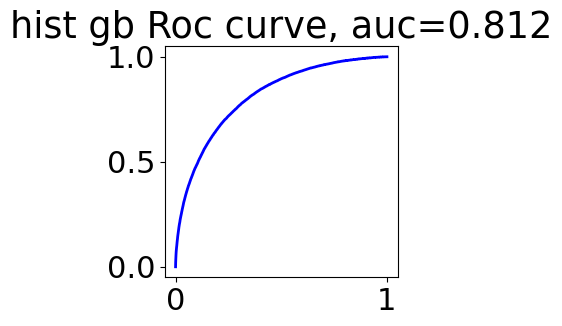

In [57]:
from sklearn.metrics import  roc_curve, roc_auc_score

train_prob = hist_gradient_boost_model.predict_proba(train_features)

fpr, tpr, thresholds = roc_curve(train_labels, train_prob[:, 1])
auc = roc_auc_score(train_labels, train_prob[:, 1])

plt.figure(figsize=(3,3))
plt.plot(fpr, tpr, color='blue', lw=2)
plt.title(f'hist gb Roc curve, auc={auc:.3f}')

In [58]:
import time
import os

def submit(ids, pred, name, feature_count=None):
    """
    ids: 测试集的 SK_ID_CURR
    pred: 模型预测概率
    name: 你的实验备注 (如 'lgb_v1', 'baseline')
    feature_count: 可选，记录模型使用了多少个特征
    """
    # 1. 创建提交 DataFrame
    submit_df = pd.DataFrame({
        'SK_ID_CURR': ids,
        'TARGET': pred
    })

    # 2. 生成时间戳 (格式: 0213_1530)
    timestamp = time.strftime("%m%d_%H%M")
    
    # 3. 构造文件名
    # 格式: 0213_1530_lgb_v1_f542.csv
    f_str = f"_f{feature_count}" if feature_count else ""
    filename = f"{timestamp}_{name}{f_str}.csv"
    
    # 4. 确保保存目录存在 (可选)
    if not os.path.exists('submissions'):
        os.makedirs('submissions')
    
    save_path = os.path.join('submissions', filename)
    
    # 5. 保存并打印提示
    submit_df.to_csv(save_path, index=False)
    
    return submit_df


In [61]:
hist_gradient_boost_model_pred = hist_gradient_boost_model.predict_proba(test_features)
submit_df = submit(test['SK_ID_CURR'], hist_gradient_boost_model_pred[:, 1], 
    name='hgbm_baseline',
    feature_count=train_features.shape[1]
    )
submit_df.head()


,SK_ID_CURR,TARGET
307511,100001,0.047845
307512,100005,0.114776
307513,100013,0.023606
307514,100028,0.038234
307515,100038,0.167165


得分76，和手动工程相差不多，特征数也差不多

### lgbm

In [62]:
import re
# 1. 定义清理函数
def clean_names(df):
    # 替换所有非字母、数字的字符为下划线
    # 这里的正则 [^A-Za-z0-9_] 会匹配空格、斜杠、括号等所有特殊字符
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', col) for col in df.columns]
    # 顺便处理一下可能出现的重复下划线，比如 __
    df.columns = [re.sub(r'_+', '_', col).strip('_') for col in df.columns]
    return df

In [63]:
train_features = clean_names(train_features)
test_features = clean_names(test_features)

from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier(
    n_estimators=100,      # 对应 max_iter，树的个数
    learning_rate=0.1,     # 学习率
    max_depth=3,           # 树的最大深度
    random_state=42,       # 保证结果可复现
    n_jobs=-1              # 使用所有 CPU 核心加速
)
lgbm_model.fit(train_features, train_labels)


[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.679221 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 90425
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 1088
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

LGBMClassifier(max_depth=3, n_jobs=-1, random_state=42)

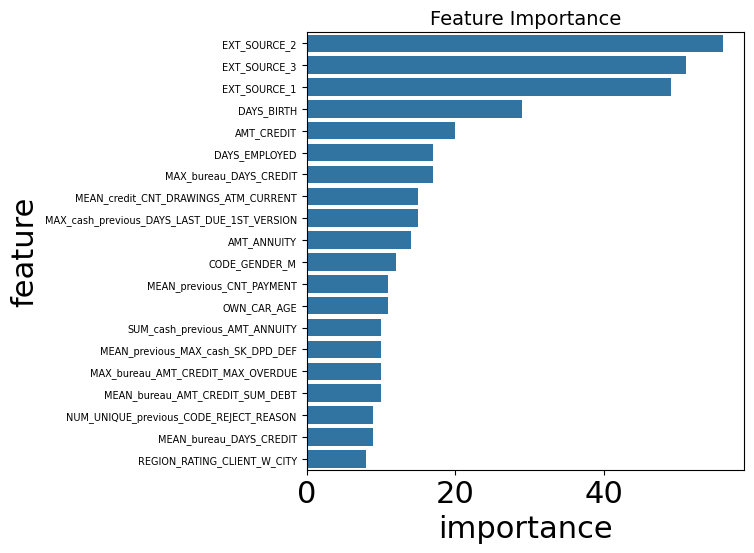

In [71]:
features_importance = pd.DataFrame(
    {
        'importance': lgbm_model.feature_importances_,
        'feature': lgbm_model.feature_name_
    }
)
features_importance_plot = features_importance.sort_values(by='importance', ascending=False).head(20)

plt.figure(figsize=(8, 6), dpi=100) 
sns.barplot(data=features_importance_plot, x='importance', y='feature')

plt.yticks(fontsize=7) # 进一步微调
plt.title('Feature Importance', fontsize=14)
plt.tight_layout()

可以看到，和之前手动特征工程结果几乎一样。这是符合的。

思想过程几乎一样，一个自动一个手动而已